# Data Loading & Exploratory Data Analysis (EDA).

Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


Load the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('/content/heart_disease_uci.csv')

# Drop the 'id' column as it has no predictive value
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# Display basic information
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns\n")
print("First 5 rows:")
display(df.head())

Dataset Shape: 920 rows and 15 columns

First 5 rows:


,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


Check for Missing Data

Columns with Missing Values:
 ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
dtype: int64


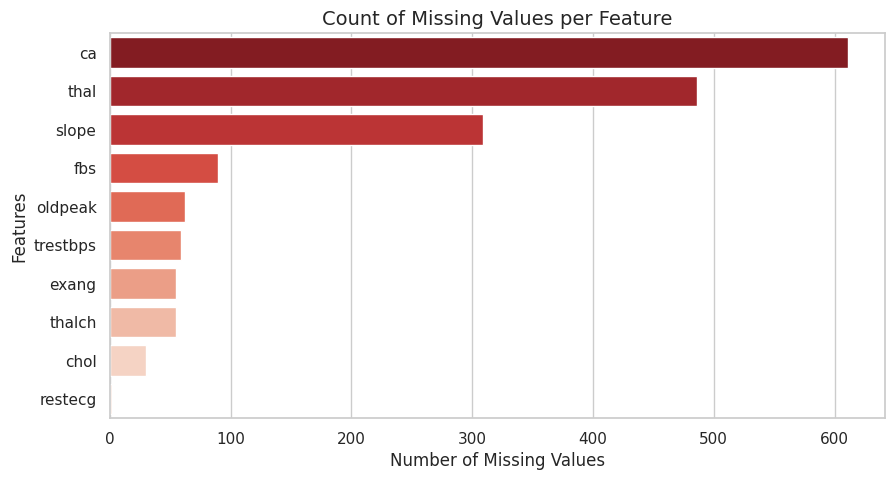

In [3]:
# Check missing values
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

print("Columns with Missing Values:\n", missing_data)

# Visualize missing data
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_data.values, y=missing_data.index, palette="Reds_r")
plt.title('Count of Missing Values per Feature', fontsize=14)
plt.xlabel('Number of Missing Values')
plt.ylabel('Features')
plt.show()

Transform & Visualize the Target Variable

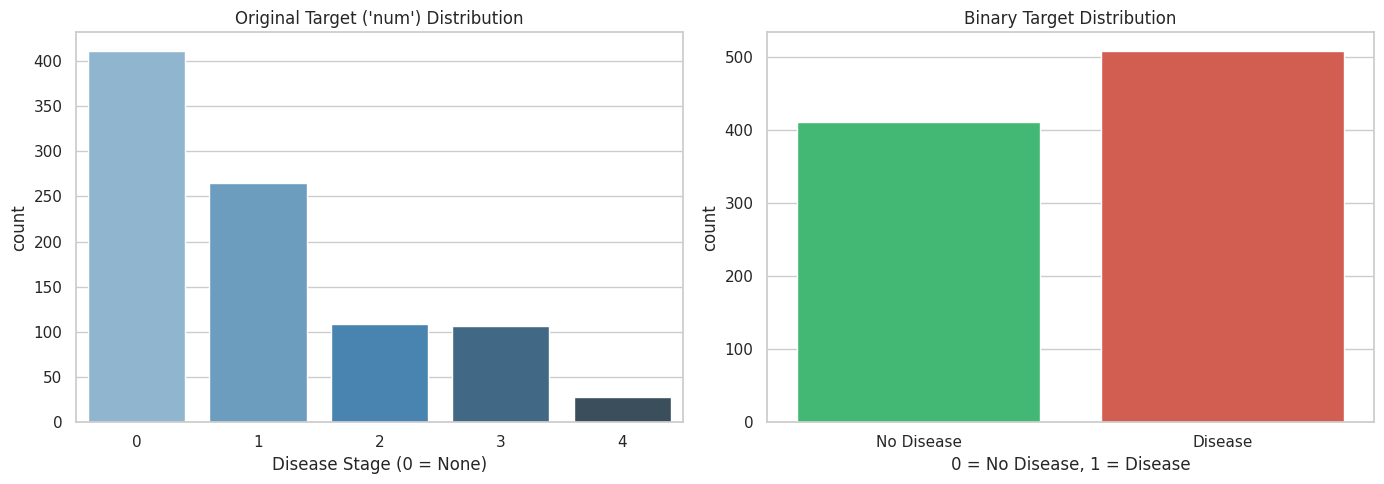

In [4]:
# Create a binary target: 0 = No Heart Disease, 1 = Heart Disease
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

# Visualize the original vs. binary target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original multi-class target
sns.countplot(data=df, x='num', ax=axes[0], palette="Blues_d")
axes[0].set_title("Original Target ('num') Distribution")
axes[0].set_xlabel("Disease Stage (0 = None)")

# New binary target
sns.countplot(data=df, x='target', ax=axes[1], palette=["#2ecc71", "#e74c3c"])
axes[1].set_title("Binary Target Distribution")
axes[1].set_xlabel("0 = No Disease, 1 = Disease")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

df = df.drop(columns=['num'])

Distribution of Numerical Features

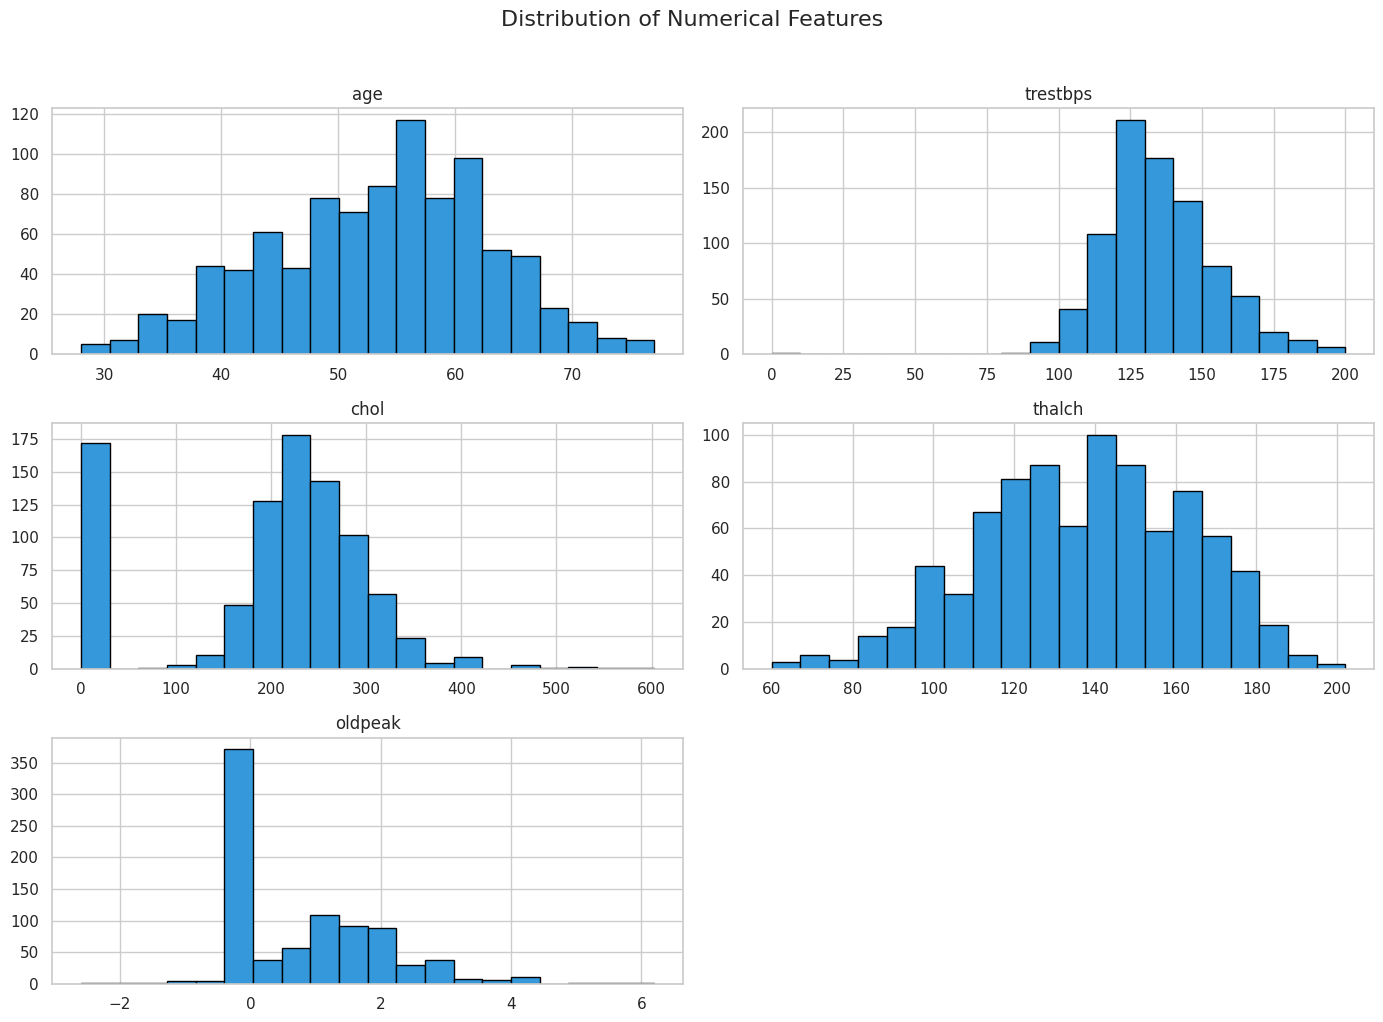

In [5]:
numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

df[numerical_cols].hist(bins=20, figsize=(14, 10), color='#3498db', edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Visualizing Key Relationships

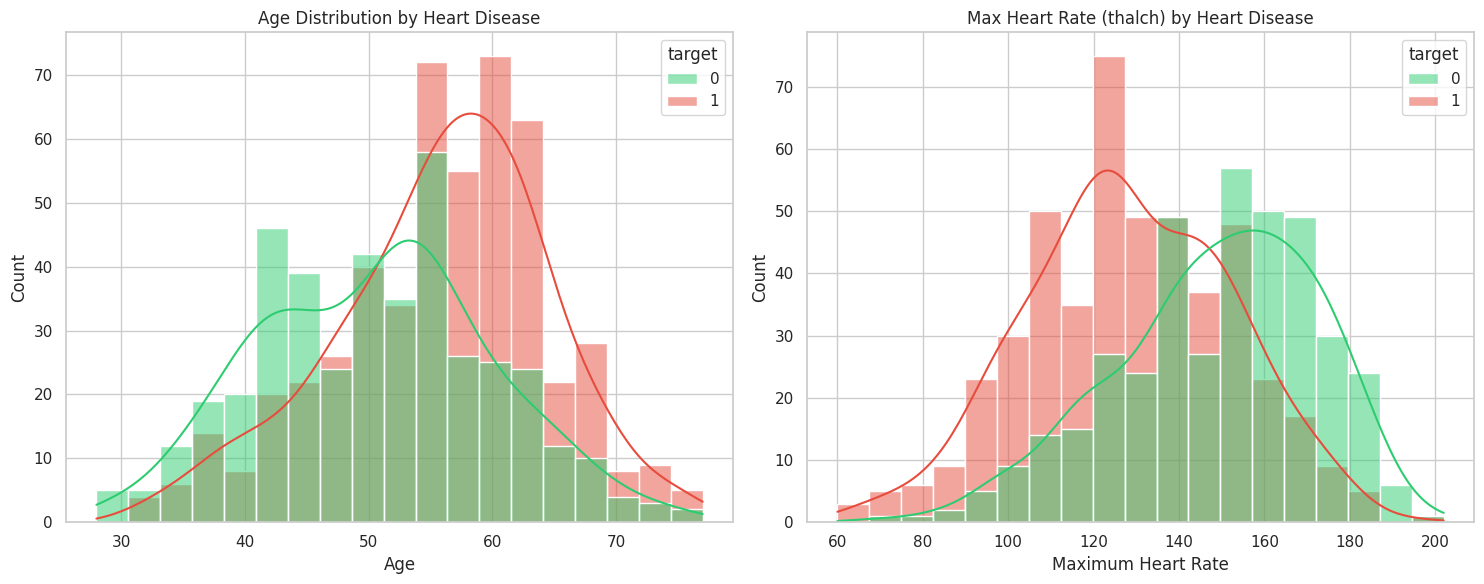

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(data=df, x='age', hue='target', kde=True, ax=axes[0], palette=["#2ecc71", "#e74c3c"])
axes[0].set_title('Age Distribution by Heart Disease')
axes[0].set_xlabel('Age')

sns.histplot(data=df, x='thalch', hue='target', kde=True, ax=axes[1], palette=["#2ecc71", "#e74c3c"])
axes[1].set_title('Max Heart Rate (thalch) by Heart Disease')
axes[1].set_xlabel('Maximum Heart Rate')

plt.tight_layout()
plt.show()

Correlation Heatmap

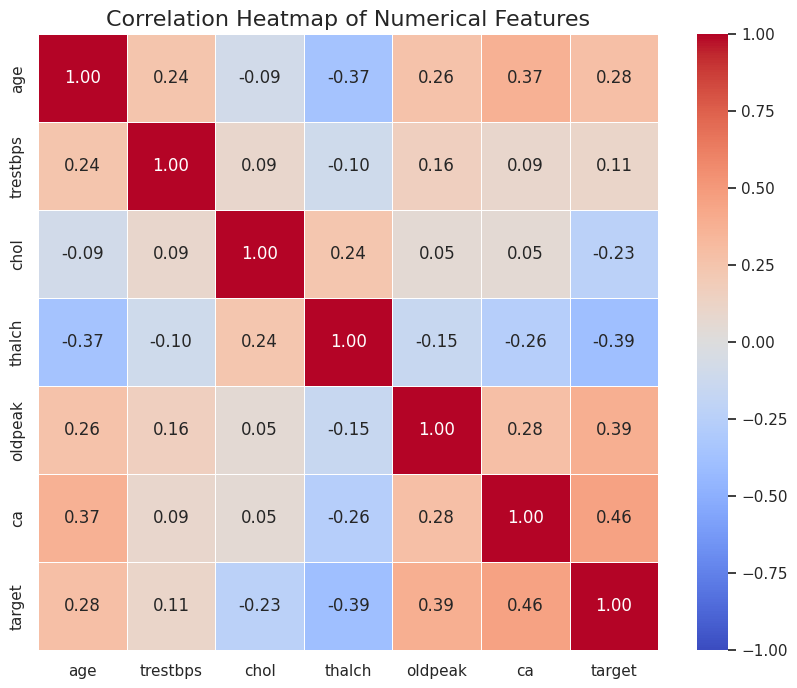

In [7]:
plt.figure(figsize=(10, 8))
# Calculate correlation only for numerical columns
corr = df.select_dtypes(include=[np.number]).corr()

# Create a heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

# Advanced Data Preprocessing

Define Feature Types & Split Data

In [8]:
# Separate features (X) and target (y)
X = df.drop(columns=['target'])
y = df['target']

# Identify numerical and categorical columns
# 'ca' is technically numerical (number of vessels), but treated as discrete
numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
categorical_cols = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

Numerical columns (6): ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical columns (8): ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


Advanced Missing Value Imputation

In [9]:
from sklearn.impute import KNNImputer, SimpleImputer

# 1. Impute Categorical columns with the most frequent value (Mode)
cat_imputer = SimpleImputer(strategy='most_frequent')
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

# 2. Impute Numerical columns using KNN Imputer
# use 5 nearest neighbors to estimate missing clinical values
knn_imputer = KNNImputer(n_neighbors=5)
X[numerical_cols] = knn_imputer.fit_transform(X[numerical_cols])

print("Remaining missing values:\n", X.isnull().sum().sum())

Remaining missing values:
 0


Encoding Categorical Variables (One-Hot Encoding)

In [10]:
# Perform One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Convert boolean columns to integers (1 and 0) if pd.get_dummies outputted booleans
X_encoded = X_encoded.astype(float)

print(f"Original feature count: {X.shape[1]}")
print(f"Encoded feature count: {X_encoded.shape[1]}")
display(X_encoded.head(3))

Original feature count: 14
Encoded feature count: 21


,age,trestbps,chol,thalch,oldpeak,ca,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,...,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63.0,145.0,233.0,150.0,2.3,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,67.0,160.0,286.0,108.0,1.5,3.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
2,67.0,120.0,229.0,129.0,2.6,2.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0


Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Create a copy to avoid overwriting the original encoded dataframe entirely yet
X_scaled = X_encoded.copy()

# Scale only the numerical columns
X_scaled[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

print("Data successfully scaled! Here is how the numerical features look now:")
display(X_scaled[numerical_cols].head(3))

Data successfully scaled! Here is how the numerical features look now:


,age,trestbps,chol,thalch,oldpeak,ca
0,1.007386,0.682314,0.304813,0.511879,1.336557,-1.170087
1,1.432034,1.488735,0.790166,-1.138819,0.584615,3.320236
2,1.432034,-0.661721,0.268183,-0.313470,1.618535,1.823461


Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (736, 21)
Testing Data Shape: (184, 21)


# Model Building & Evaluation.

Train the Random Forest Model

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42, class_weight='balanced')

rf_model.fit(X_train, y_train)

print("Random Forest Model successfully trained!")

Random Forest Model successfully trained!


Make Predictions and Evaluate Performance

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the unseen test set
y_pred = rf_model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Print detailed Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease (0)', 'Disease (1)']))

Model Accuracy: 85.33%

Classification Report:
                precision    recall  f1-score   support

No Disease (0)       0.86      0.80      0.83        82
   Disease (1)       0.85      0.89      0.87       102

      accuracy                           0.85       184
     macro avg       0.85      0.85      0.85       184
  weighted avg       0.85      0.85      0.85       184



Visualize the Confusion Matrix

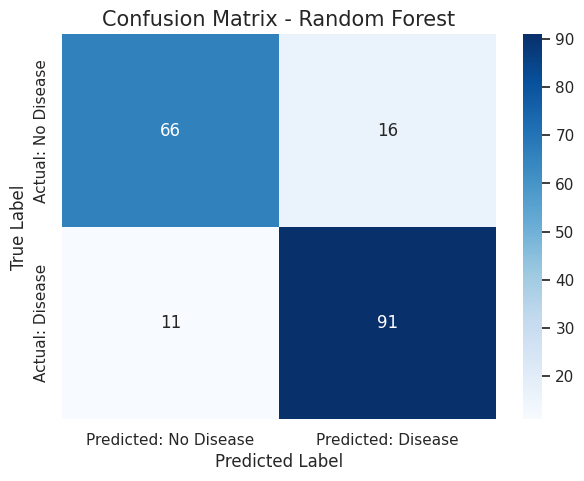

In [15]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No Disease', 'Predicted: Disease'],
            yticklabels=['Actual: No Disease', 'Actual: Disease'])

plt.title('Confusion Matrix - Random Forest', fontsize=15)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

ROC-AUC Curve

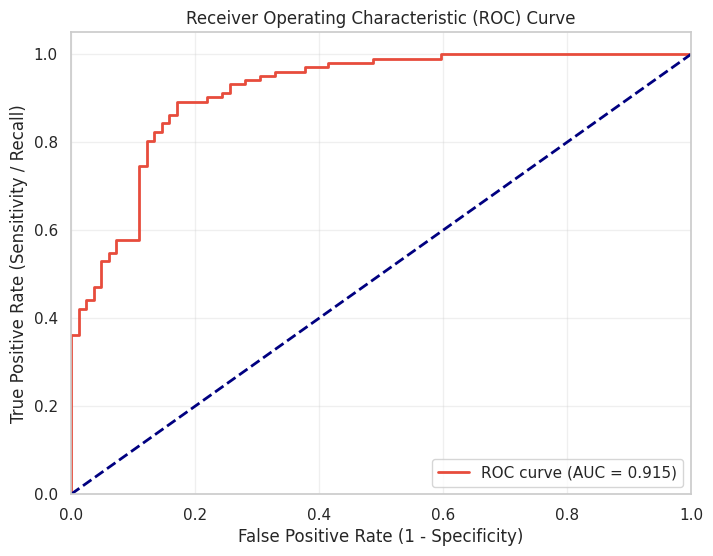

In [16]:
from sklearn.metrics import roc_curve, auc

y_prob = rf_model.predict_proba(X_test)[:, 1]

# Calculate False Positive Rate (fpr) and True Positive Rate (tpr)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

Test the Model with a Single Patient

In [19]:
# 1. Pick a single patient from the test set
patient_idx = 5
sample_patient = X_test.iloc[[patient_idx]]

# 2. Get the model's prediction (0 = No Disease, 1 = Disease)
prediction = rf_model.predict(sample_patient)[0]

# 3. Get the model's confidence (probability)
probabilities = rf_model.predict_proba(sample_patient)[0]
prob_no_disease = probabilities[0] * 100
prob_disease = probabilities[1] * 100

# 4. Display the results clearly
print("-"*40)
print(f"MODEL PREDICTION FOR PATIENT #{ patient_idx}")
print("-"*40)

if prediction == 1:
    print("Diagnosis: HEART DISEASE DETECTED")
else:
    print("Diagnosis: NO HEART DISEASE")

print(f"\nModel Confidence:")
print(f" - Chance of No Disease: {prob_no_disease:.1f}%")
print(f" - Chance of Disease:    {prob_disease:.1f}%")

print("\nPatient's Scaled Clinical Features (Input to Model):")
display(sample_patient)

----------------------------------------
MODEL PREDICTION FOR PATIENT #5
----------------------------------------
Diagnosis: HEART DISEASE DETECTED

Model Confidence:
 - Chance of No Disease: 19.3%
 - Chance of Disease:    80.7%

Patient's Scaled Clinical Features (Input to Model):


,age,trestbps,chol,thalch,oldpeak,ca,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,...,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
483,0.582737,-0.124107,1.08321,-0.667191,0.114651,1.823461,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0


# Explaining Predictions with LIME

**The Problem:** Our Random Forest model is highly accurate, but it is a "Black Box." When it says a patient has an 85% chance of heart disease, the doctors don't know why.

**The LIME Solution:** LIME acts like a detective interrogating our model. Here is exactly how LIME figures out the "why" for a single patient:



  1.It takes the patient's data: LIME looks at the specific patient we want to
explain.

  2.It creates fake patients: LIME generates hundreds of "fake" variations of this patient by slightly tweaking their age, cholesterol, heart rate, etc.

  3.It asks the Black Box: LIME feeds all these fake patients into the Random Forest to see how the predictions change. (e.g., "If this patient's cholesterol was 20 points lower, would you still say they are sick?")

  4.It builds a transparent model: LIME uses the results from the fake patients to draw a simple, straight line (Linear Regression) right through that specific local area of data.

  5.It weighs the evidence: Because a straight line is easy to read, LIME can now tell us exactly which features pushed the probability up (towards Disease) and which features pushed it down (towards Healthy) for this specific patient.

Install LIME

In [20]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 23.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=0b00863e2f861f86ff5535ba68cdb7595441dc7df199b8b9a5b0d904aa95f665
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


Initialize the LIME Explainer

In [21]:
import lime
import lime.lime_tabular

# Create the LIME Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,            # LIME needs the training data as a numpy array
    feature_names=X_train.columns.tolist(),  # The names of our clinical features
    class_names=['No Disease', 'Disease'],   # The names of our target classes
    mode='classification',                   # We are predicting categories, not continuous numbers
    random_state=42                          # For reproducible explanations
)

print("LIME Explainer initialized successfully!")

LIME Explainer initialized successfully!


Explain the Patient #5

In [25]:
# 1. Grab the exact same patient we tested earlier (patient_idx = 5)
patient_data = X_test.iloc[patient_idx]

# 2. Ask LIME to explain the model's prediction for this specific patient
# We pass the patient's data, and the model's predict_proba function
explanation = explainer.explain_instance(
    data_row=patient_data.values,
    predict_fn=rf_model.predict_proba,
    num_features=6 # Show the top 6 most important features for this decision
)

explanation.show_in_notebook(show_table=True, show_all=False)

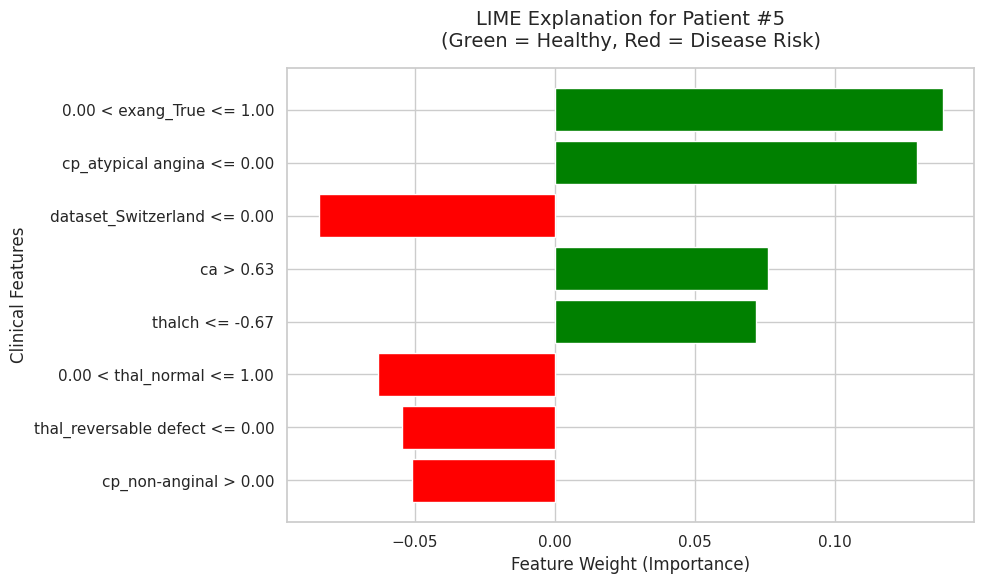


Patient's Actual Clinical Values
age: 0.58
trestbps: -0.12
chol: 1.08
thalch: -0.67
oldpeak: 0.11
ca: 1.82
sex_Male: 1.00
dataset_Hungary: 1.00
dataset_Switzerland: 0.00
dataset_VA Long Beach: 0.00
cp_atypical angina: 0.00
cp_non-anginal: 1.00
cp_typical angina: 0.00
fbs_True: 0.00
restecg_normal: 1.00
restecg_st-t abnormality: 0.00
exang_True: 1.00
slope_flat: 1.00
slope_upsloping: 0.00
thal_normal: 1.00
thal_reversable defect: 0.00


In [24]:
import matplotlib.pyplot as plt

# 1. Grab the exact same patient we tested earlier (patient_idx = 5)
patient_data = X_test.iloc[patient_idx]

# 2. Ask LIME to explain the model's prediction
explanation = explainer.explain_instance(
    data_row=patient_data.values,
    predict_fn=rf_model.predict_proba,
    num_features=8 # Showing top 8 features
)

fig = explanation.as_pyplot_figure()

fig.set_size_inches(10, 6)
plt.title(f"LIME Explanation for Patient #{patient_idx}\n(Green = Healthy, Red = Disease Risk)", fontsize=14, pad=15)
plt.xlabel("Feature Weight (Importance)", fontsize=12)
plt.ylabel("Clinical Features", fontsize=12)
plt.tight_layout()

plt.savefig('lime_explanation_patient_5.png', dpi=300, bbox_inches='tight')

plt.show()

print("\nPatient's Actual Clinical Values")
for feature, value in zip(X_test.columns, patient_data.values):
    print(f"{feature}: {value:.2f}")

How to Interpret this LIME Explanation
The chart above represents the "brain" of our Random Forest model for this specific patient. Because the model predicted a high probability of Heart Disease, LIME helps us understand exactly which clinical features led to that diagnosis.

Here is how to read the chart:

1. The Y-Axis (The Clinical Features)
On the left side, you will see the features that LIME identified as the most important for this specific patient. LIME often groups continuous variables into brackets. For example, seeing thalch <= 133.00 means the patient's maximum heart rate was 133 or lower, and the model heavily considered this fact.

2. The X-Axis (Feature Weight / Importance)
The horizontal axis represents how strongly a feature pushed the model's decision.

A weight of 0.00 means the feature had no impact.

A weight of 0.15 is a very strong push in one direction.

3. The Bars (Direction and Length)

Direction: * Bars pointing to the Right (Positive) push the model's prediction toward Disease.

Bars pointing to the Left (Negative) push the model's prediction toward No Disease (Healthy).

Length: The longer the bar, the more powerful that specific feature was in making the final decision.

Example Interpretation:
If the longest bar points to the right and is labeled cp_typical angina = 1, it means the fact that the patient experiences typical angina chest pain was the #1 biggest reason the model diagnosed them with heart disease. Conversely, if there is a bar pointing to the left for chol <= 200, it means the patient's healthy cholesterol level tried to convince the model they were healthy, but the other "Disease" factors ultimately outweighed it.